In [ ]:
# ==============================================================================
# SECTION 1: RNAP INACTIVATION ESTIMATION & WELL-LEVEL DECONVOLUTION
# Author: Timothé LUCAS
# Purpose: Compute raw transcription rates from deconvolution, estimate first-order
#          RNAP inactivation rates, and prepare experiment-level statistics.
# ==============================================================================

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Local deconvolution utilities
sys.path.append(r"C:\Users\ForzaPC\Desktop\repo\notebooks")
from util.utils import load_deconvolution_assets, compute_instantaneous_rate

# Configure publication-quality plot parameters (Nature/ACS guidelines)
plt.rcParams.update({
    'font.size': 10,
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# ------------------------------------------------------------------------------
# 1. DECONVOLUTION / FITTING HYPERPARAMETERS
# ------------------------------------------------------------------------------

LAMBDA_REG = 0.5           # Tikhonov regularization factor
WINDOW_MIN = 65             # Savitzky-Golay integration window (min)
T_PLATEAU_START = 150.0     # Start of the decay/plateau evaluation window (min)
T_PLOT_MAX = 320.0          # Maximum time boundary for evaluation/plotting (min)

DATA_PATH = Path(r"C:\Users\ForzaPC\Desktop\repo\data\raw_TX\TX_cleaned_data.csv")
ASSETS_PATH = Path(r"C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl")

# ------------------------------------------------------------------------------
# 2. LOAD & SANITIZE TRANSCRIPTION DATA
# ------------------------------------------------------------------------------

df = pd.read_csv(DATA_PATH)
_, f_kernel, alpha_slope, DT_MIN = load_deconvolution_assets(ASSETS_PATH)

df["time_min"] = df["Cycle"] * DT_MIN

# Keep RX+LIN constructs only, with no TopoI/Gyrase added (baseline condition)
rx_df = df[
    (df["DNA Template"].str.contains("RX|LIN", na=False))
    & (df["TopoI (U)"] <= 1e-5)
    & (df["Gyr (U)"] <= 1e-5)
].copy()

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Total rows                 : {len(df)}")
print(f"Filtered RX+LIN rows       : {len(rx_df)}")
print(f"Total experiments           : {rx_df['Exp_ID'].nunique()}")
print(f"Total wells analyzed        : {rx_df[['Exp_ID', 'Well']].drop_duplicates().shape[0]}")

# ------------------------------------------------------------------------------
# 3. WELL-LEVEL DECONVOLUTION & RNAP INACTIVATION FIT
# ------------------------------------------------------------------------------

def fit_k_inact(time_vec, v_rate, t_max_well):
    """Fit the first-order inactivation rate k_inact from the decay of v(t).

    Tries a series of increasingly permissive time windows, starting from the
    plateau region, until at least 3 points are available for a log-linear fit.
    Falls back to a near-zero rate if no window yields enough points.
    """
    candidate_windows = [
        (T_PLATEAU_START, min(T_PLOT_MAX, t_max_well)),
        (100.0, t_max_well),
        (t_max_well * 0.3, t_max_well),
        (t_max_well * 0.5, t_max_well),
    ]

    for t_start, t_end in candidate_windows:
        fit_mask = (time_vec >= t_start) & (time_vec <= t_end)
        t_fit = time_vec[fit_mask]
        v_fit = np.maximum(v_rate[fit_mask], 1e-6)

        if len(t_fit) >= 3:
            slope, *_ = stats.linregress(t_fit, np.log(v_fit))
            return -slope

    return 1e-5  # Fallback when no window has enough points


well_data = {}

for (exp_id, well_id), well_group in rx_df.groupby(["Exp_ID", "Well"]):
    well_group = well_group.sort_values("Cycle")
    rfu_signal = well_group["RFU"].values
    time_vec = well_group["time_min"].values

    dna_temp = well_group["DNA Template"].iloc[0]
    dna_conc = well_group["[DNA] (nM)"].iloc[0]
    rnap_conc = well_group["[RNAP] (nM)"].iloc[0]

    # Single deconvolution call -> cumulative RNA trace AND instantaneous rate v(t)
    rna_cum, v_rate = compute_instantaneous_rate(
        rfu_signal=rfu_signal,
        f_kernel=f_kernel,
        alpha_slope=alpha_slope,
        dt_min=DT_MIN,
        lambda_reg=LAMBDA_REG,
        window_min=WINDOW_MIN,
        polyorder=2,
        mode="nearest",
    )

    k_inact_well = fit_k_inact(time_vec, v_rate, time_vec.max())
    rna_final_abs = rna_cum[-1]
    turnover = rna_final_abs / rnap_conc if rnap_conc > 0 else np.nan

    well_data[f"{exp_id}_{well_id}"] = {
        "exp_id": exp_id,
        "well": well_id,
        "dna_temp": dna_temp,
        "dna_conc": dna_conc,
        "rnap_conc": rnap_conc,
        "time_vector": time_vec,
        "v_rate": v_rate,
        "k_inact": k_inact_well,
        "rna_final_abs": rna_final_abs,
        "turnover": turnover,
    }

df_wells = pd.DataFrame([
    {
        "Well_ID": key,
        "Exp_ID": val["exp_id"],
        "Well": val["well"],
        "RNAP": val["rnap_conc"],
        "DNA": val["dna_conc"],
        "k_inact": val["k_inact"],
        "RNA_final_abs": val["rna_final_abs"],
        "Turnover": val["turnover"],
    }
    for key, val in well_data.items()
])

print(f"\n[INFO] Number of wells processed individually: {len(df_wells)}")


Successfully loaded assets from: C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl
=== TRANSCRIPTION DATASET SUMMARY ===
Total rows                 : 15855
Filtered RX+LIN rows       : 5134
Total experiments           : 8
Total wells analyzed        : 34

[INFO] Number of wells processed individually: 34


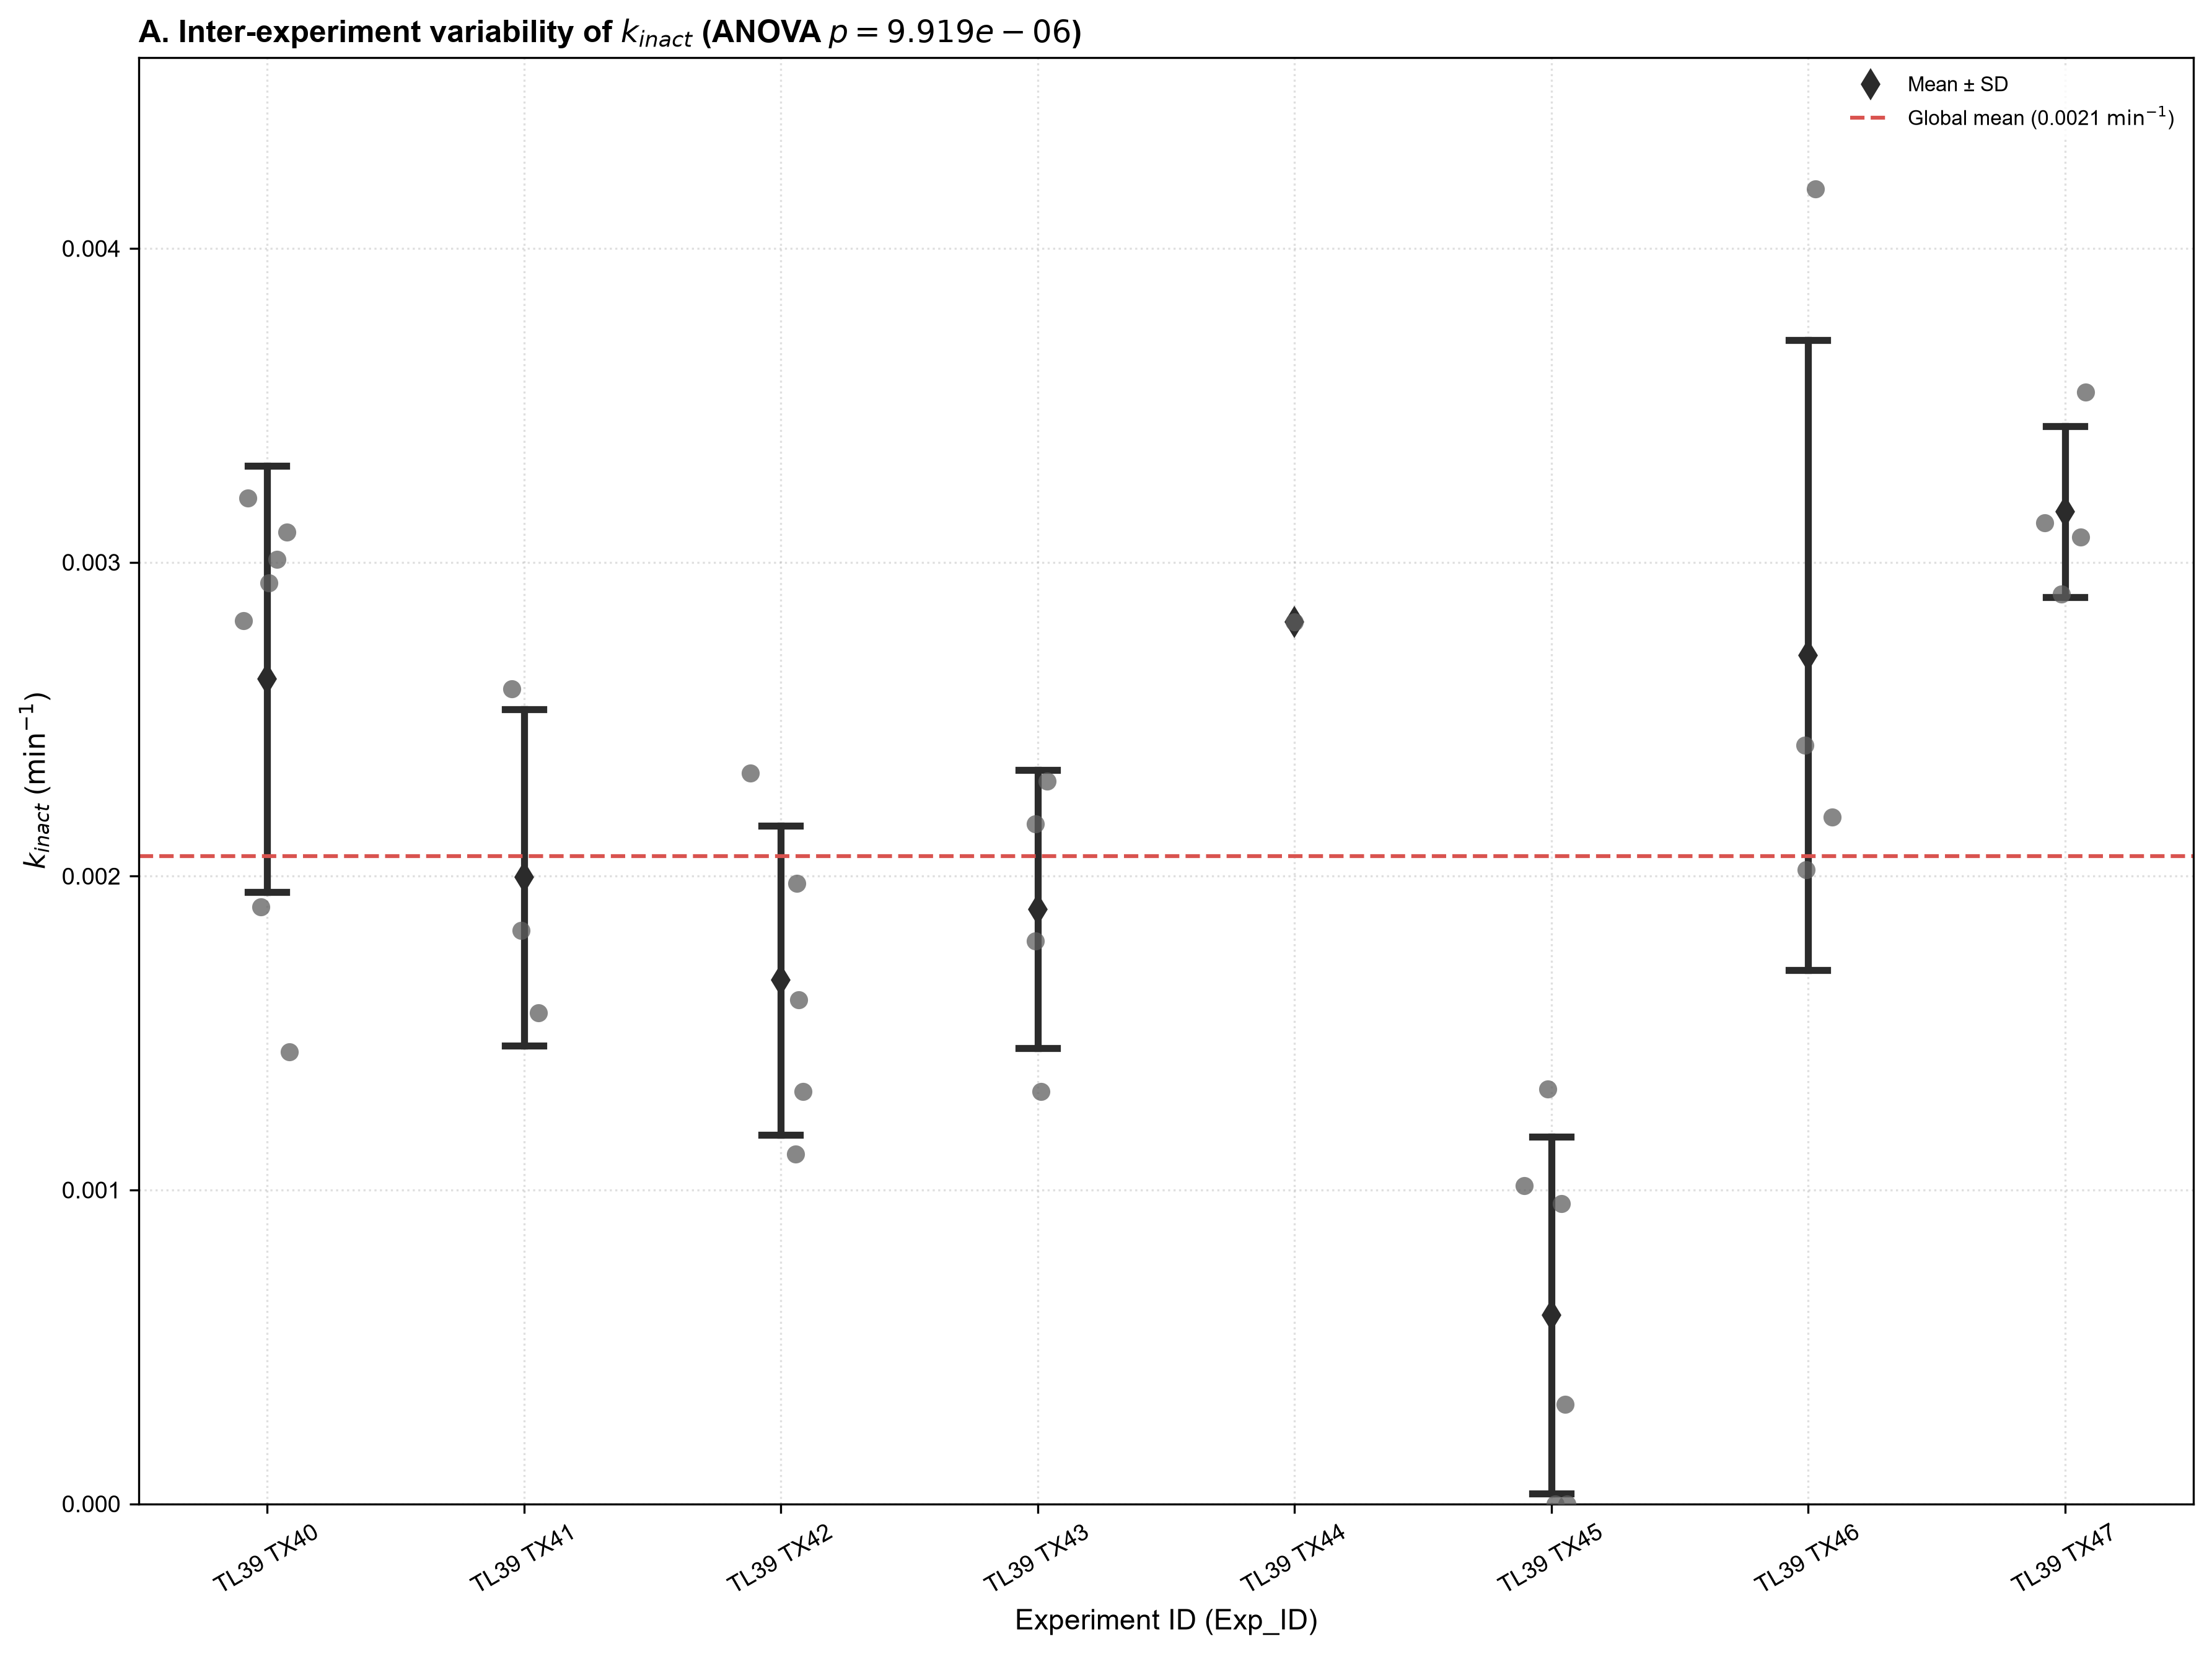

 OUTLIER WELLS (IQR CRITERION)
   Exp_ID Well  k_inact   RNAP   DNA
TL39 TX46   F4 0.004189 340.00 0.068
TL39 TX47  B10 0.003543 169.95 0.075
----------------------------------------------------------------------
 PER-EXPERIMENT SUMMARY:
----------------------------------------------------------------------
   Exp_ID  n_wells  k_inact_mean  k_inact_std  k_inact_median
TL39 TX40        7      0.002629     0.000679        0.002934
TL39 TX41        3      0.001996     0.000536        0.001827
TL39 TX42        5      0.001668     0.000492        0.001605
TL39 TX43        4      0.001894     0.000443        0.001980
TL39 TX44        1      0.002810          NaN        0.002810
TL39 TX45        6      0.000601     0.000569        0.000636
TL39 TX46        4      0.002704     0.001004        0.002303
TL39 TX47        4      0.003162     0.000272        0.003102

 ANOVA p-value (Exp_ID effect, n>=3) : 9.9185e-06
 Kruskal-Wallis p-value (n>=3)      : 1.0353e-03
 Note: Experiments with n < 3 are

C:\Users\ForzaPC\AppData\Local\Temp\ipykernel_2436\1205594931.py:367: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


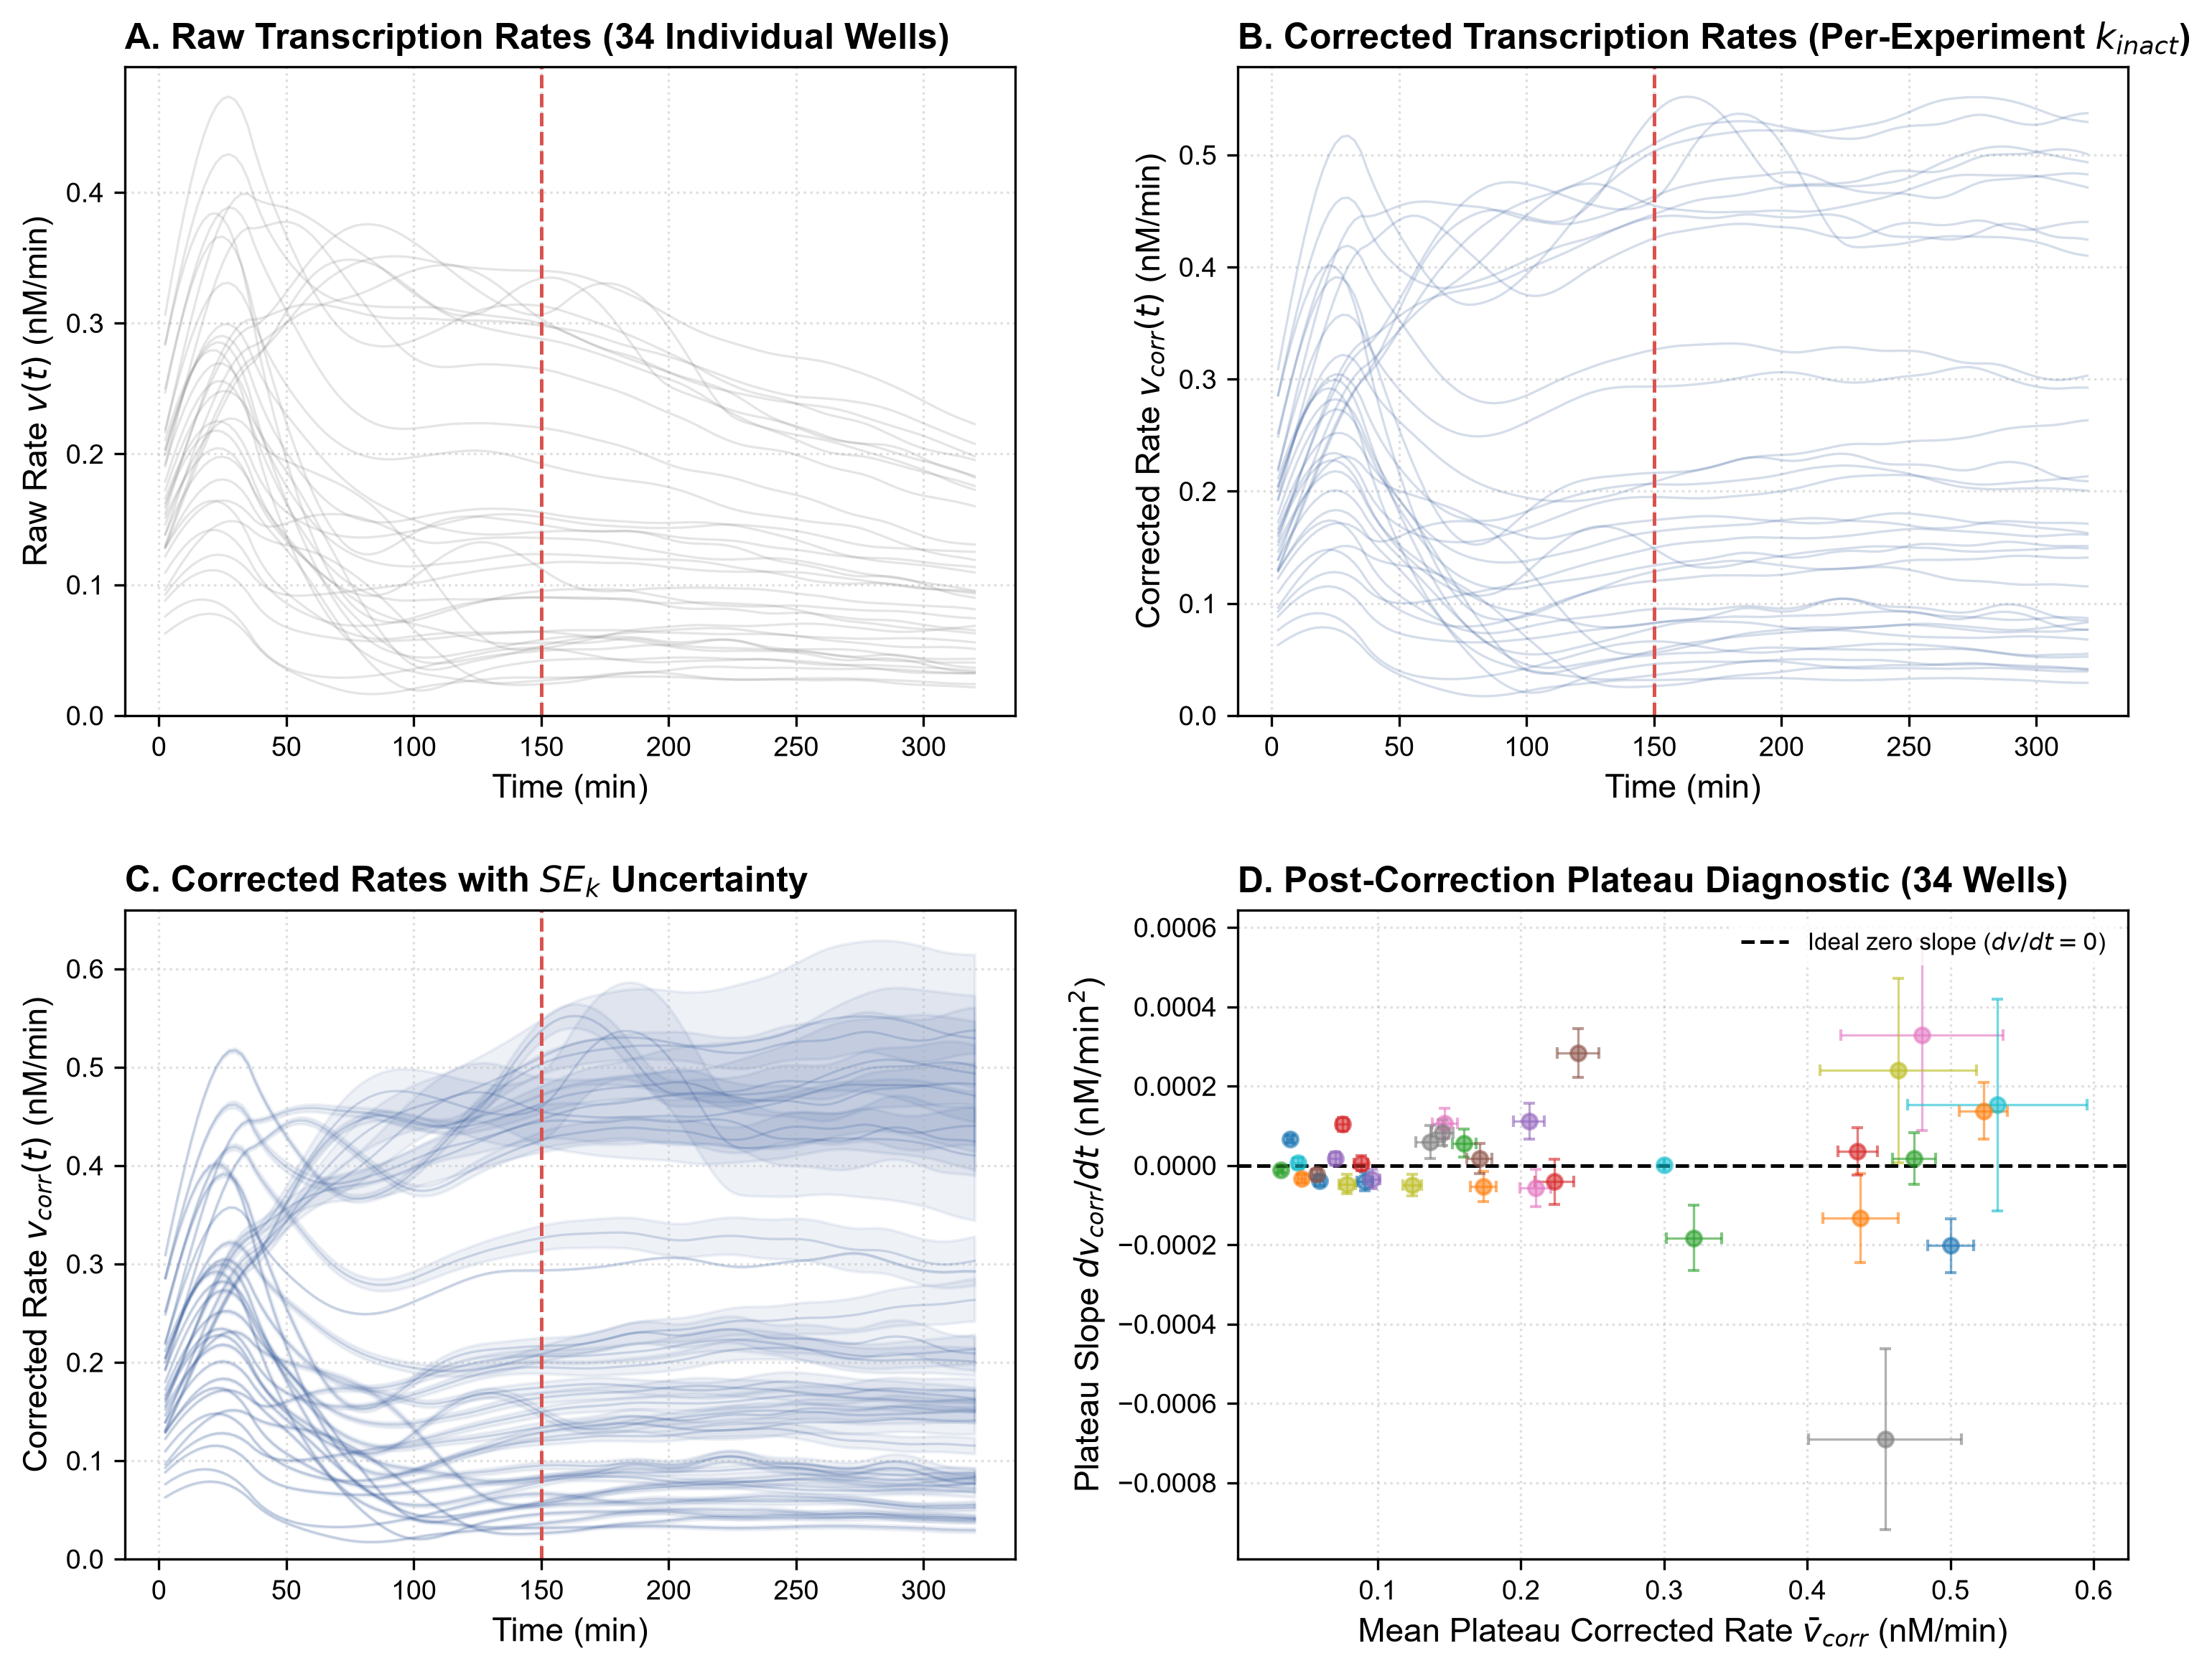


Figure exported successfully: 'figure_4_RNAP_inactivation_correction.pdf' and '.png'


In [2]:
# ==============================================================================
# SECTION 2: INTER-EXPERIMENT VARIABILITY & RNAP INACTIVATION CORRECTION
# Author: Molecular Transcription Group
# Purpose: Quantify experiment-level k_inact, identify outliers, apply the
#          experiment-specific correction, and generate publication-ready figures.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. INTER-EXPERIMENT k_inact VARIABILITY & OUTLIER DETECTION
# ------------------------------------------------------------------------------

def analyze_k_inact(df_wells_input):
    """Analyze k_inact variability across experiments using all wells.

    Parameters
    ----------
    df_wells_input : pd.DataFrame
        Well-level data with at least 'Exp_ID', 'Well', and 'k_inact'.

    Returns
    -------
    df_plot : pd.DataFrame
        The full dataset used for the analysis.
    df_exp_summary : pd.DataFrame
        Per-experiment k_inact summary statistics.
    """
    df = df_wells_input.copy()

    # Replace negative k_inact values with zero
    df["k_inact"] = df["k_inact"].clip(lower=0)

    # Outlier detection per experiment (Tukey's IQR rule, upper tail only)
    outlier_indices = []

    for exp_id, group in df.groupby("Exp_ID"):
        q1, q3 = group["k_inact"].quantile([0.25, 0.75])
        upper_bound = q3 + 1.5 * (q3 - q1)
        outlier_indices.extend(group[group["k_inact"] > upper_bound].index.tolist())

    df_outliers = df.loc[outlier_indices].copy()
    df_plot = df.copy()

    df_exp_summary = (
        df_plot.groupby("Exp_ID")["k_inact"]
        .agg(
            n_wells="count",
            k_inact_mean="mean",
            k_inact_std="std",
            k_inact_median="median",
        )
        .reset_index()
    )

    k_global_mean = df_plot["k_inact"].mean()

    # Filtering for statistical tests (keep only groups with n >= 3)
    exp_groups_stats = [
        g["k_inact"].dropna().values
        for _, g in df_plot.groupby("Exp_ID")
        if len(g["k_inact"].dropna()) >= 3
    ]

    if len(exp_groups_stats) > 1:
        _, p_val_anova = stats.f_oneway(*exp_groups_stats)
        _, p_val_kruskal = stats.kruskal(*exp_groups_stats)
    else:
        p_val_anova, p_val_kruskal = 1.0, 1.0

    # Publication-style variability plot
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111)
    exp_order = list(df_exp_summary["Exp_ID"].unique())

    sns.pointplot(
        data=df_plot,
        x="Exp_ID",
        y="k_inact",
        order=exp_order,
        ax=ax,
        linestyle="none",
        errorbar="sd",
        capsize=0.15,
        color="#2b2b2b",
        markers="d",
        markersize=6,
        label="Mean ± SD",
    )

    sns.stripplot(
        data=df_plot,
        x="Exp_ID",
        y="k_inact",
        order=exp_order,
        ax=ax,
        color="#5f5f5f",
        size=7,
        jitter=0.12,
        alpha=0.75,
    )

    ax.axhline(
        k_global_mean,
        color="#d9534f",
        linestyle="--",
        linewidth=1.5,
        label=rf"Global mean ({k_global_mean:.4f} $\mathrm{{min}}^{{-1}}$)",
    )

    ax.set_xlabel("Experiment ID (Exp_ID)")
    ax.set_ylabel(r"$k_{inact}$ ($\mathrm{min}^{-1}$)")
    ax.set_title(
        r"A. Inter-experiment variability of $k_{inact}$ "
        f"(ANOVA $p = {p_val_anova:.3e}$)",
        fontweight="bold",
        loc="left",
    )
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(bottom=0, top=max(df_plot["k_inact"].max() * 1.1, 1e-4))
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    ax.grid(True, linestyle=":", alpha=0.4)

    plt.tight_layout()

    fig.savefig(
        r"C:\Users\ForzaPC\Desktop\repo\figures\figure_3_k_inact_variability.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        r"C:\Users\ForzaPC\Desktop\repo\figures\figure_3_k_inact_variability.png",
        format="png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("=" * 70)
    print(" OUTLIER WELLS (IQR CRITERION)")
    print("=" * 70)

    if not df_outliers.empty:
        print(df_outliers[["Exp_ID", "Well", "k_inact", "RNAP", "DNA"]].to_string(index=False))
    else:
        print("No outliers detected (IQR criterion).")

    print("-" * 70)
    print(" PER-EXPERIMENT SUMMARY:")
    print("-" * 70)
    print(df_exp_summary.to_string(index=False))
    print(f"\n ANOVA p-value (Exp_ID effect, n>=3) : {p_val_anova:.4e}")
    print(f" Kruskal-Wallis p-value (n>=3)      : {p_val_kruskal:.4e}")
    print(" Note: Experiments with n < 3 are excluded from ANOVA/Kruskal.")
    print("=" * 70)

    return df_plot, df_exp_summary


# Execute the experiment-level analysis
df_plot_all, summary_all = analyze_k_inact(df_wells)

# ------------------------------------------------------------------------------
# 2. MERGE EXPERIMENT-LEVEL k_inact METRICS
# ------------------------------------------------------------------------------

rx_kinact_df = rx_df.copy()
exp_metrics = summary_all.copy()

exp_metrics["k_inact_se"] = exp_metrics.apply(
    lambda row: (
        row["k_inact_std"] / np.sqrt(row["n_wells"])
        if (pd.notna(row["k_inact_std"]) and row["n_wells"] > 1)
        else 0.0
    ),
    axis=1,
)

cols_to_merge = ["Exp_ID", "k_inact_mean", "k_inact_std", "k_inact_se"]

rx_kinact_df = rx_kinact_df.merge(
    exp_metrics[cols_to_merge],
    on="Exp_ID",
    how="left",
).rename(
    columns={
        "k_inact_mean": "k_inact_exp_mean",
        "k_inact_std": "k_inact_exp_sd",
        "k_inact_se": "k_inact_exp_se",
    }
)

print("\n=== EXPERIMENT-LEVEL k_inact METRICS ===")
print(
    rx_kinact_df[
        ["Exp_ID", "Well", "k_inact_exp_mean", "k_inact_exp_sd", "k_inact_exp_se"]
    ].drop_duplicates().head()
)

# ------------------------------------------------------------------------------
# 3. RNAP INACTIVATION CORRECTION
# ------------------------------------------------------------------------------

# Fast lookup of experiment-specific k_inact values
exp_k_map = (
    rx_kinact_df.groupby("Exp_ID")
    .agg(
        k_mean=("k_inact_exp_mean", "first"),
        k_se=("k_inact_exp_se", "first"),
    )
    .to_dict(orient="index")
)

n_wells = len(df_wells)

# Publication figure layout: same overall dimensions and panel organization
# as the calibration/deconvolution notebook.
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# Panel A: Raw transcription rates
ax_a = fig.add_subplot(gs[0, 0])

for info in well_data.values():
    t_mask = info["time_vector"] <= T_PLOT_MAX
    ax_a.plot(
        info["time_vector"][t_mask],
        info["v_rate"][t_mask],
        color="gray",
        lw=0.8,
        alpha=0.20,
    )

ax_a.axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
ax_a.set_xlabel("Time (min)")
ax_a.set_ylabel("Raw Rate $v(t)$ (nM/min)")
ax_a.set_title(
    f"A. Raw Transcription Rates ({n_wells} Individual Wells)",
    fontweight="bold",
    loc="left",
)
ax_a.set_ylim(bottom=0)
ax_a.grid(True, linestyle=":", alpha=0.4)

# Panel B: Corrected rates using experiment-specific k_inact
ax_b = fig.add_subplot(gs[0, 1])

for info in well_data.values():
    exp_id = info["exp_id"]
    k_exp = exp_k_map[exp_id]["k_mean"]

    t_mask = info["time_vector"] <= T_PLOT_MAX
    t_plot = info["time_vector"][t_mask]
    v_corr = info["v_rate"][t_mask] * np.exp(k_exp * t_plot)

    ax_b.plot(
        t_plot,
        v_corr,
        color="#2f5597",
        lw=0.8,
        alpha=0.20,
    )

ax_b.axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
ax_b.set_xlabel("Time (min)")
ax_b.set_ylabel("Corrected Rate $v_{corr}(t)$ (nM/min)")
ax_b.set_title(
    r"B. Corrected Transcription Rates (Per-Experiment $k_{inact}$)",
    fontweight="bold",
    loc="left",
)
ax_b.set_ylim(bottom=0)
ax_b.grid(True, linestyle=":", alpha=0.4)

# Panel C: Corrected rates with propagated uncertainty from SE_k
ax_c = fig.add_subplot(gs[1, 0])

for info in well_data.values():
    exp_id = info["exp_id"]
    k_exp = exp_k_map[exp_id]["k_mean"]
    k_se_exp = exp_k_map[exp_id]["k_se"]

    t_mask = info["time_vector"] <= T_PLOT_MAX
    t_plot = info["time_vector"][t_mask]
    v_val = info["v_rate"][t_mask]

    v_corr = v_val * np.exp(k_exp * t_plot)
    v_corr_err = v_val * t_plot * np.exp(k_exp * t_plot) * k_se_exp

    ax_c.plot(
        t_plot,
        v_corr,
        color="#2f5597",
        lw=0.8,
        alpha=0.20,
    )
    ax_c.fill_between(
        t_plot,
        np.maximum(v_corr - v_corr_err, 0),
        v_corr + v_corr_err,
        color="#2f5597",
        alpha=0.08,
    )

ax_c.axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
ax_c.set_xlabel("Time (min)")
ax_c.set_ylabel("Corrected Rate $v_{corr}(t)$ (nM/min)")
ax_c.set_title(
    r"C. Corrected Rates with $SE_{k}$ Uncertainty",
    fontweight="bold",
    loc="left",
)
ax_c.set_ylim(bottom=0)
ax_c.grid(True, linestyle=":", alpha=0.4)

# Panel D: Post-correction plateau diagnostic
ax_d = fig.add_subplot(gs[1, 1])

for info in well_data.values():
    exp_id = info["exp_id"]
    k_exp = exp_k_map[exp_id]["k_mean"]
    k_se_exp = exp_k_map[exp_id]["k_se"]

    t_vec = info["time_vector"]
    v_corr = info["v_rate"] * np.exp(k_exp * t_vec)

    plat_mask = (t_vec >= T_PLATEAU_START) & (t_vec <= T_PLOT_MAX)
    t_plat = t_vec[plat_mask]
    v_plat = v_corr[plat_mask]

    if len(t_plat) >= 3:
        slope_corr, *_ = stats.linregress(t_plat, v_plat)
        mean_plat_rate = np.mean(v_plat)

        # Propagate the SE of k_inact to the plateau mean and slope
        mean_t_plat = np.mean(t_plat)
        x_err = mean_plat_rate * mean_t_plat * k_se_exp
        y_err = mean_plat_rate * k_se_exp

        ax_d.errorbar(
            mean_plat_rate,
            slope_corr,
            xerr=x_err,
            yerr=y_err,
            fmt="o",
            ms=5,
            capsize=2,
            alpha=0.6,
            elinewidth=0.8,
        )

ax_d.axhline(
    0,
    color="black",
    linestyle="--",
    lw=1.2,
    label="Ideal zero slope ($dv/dt = 0$)",
)
ax_d.set_xlabel(r"Mean Plateau Corrected Rate $\bar{v}_{corr}$ (nM/min)")
ax_d.set_ylabel(r"Plateau Slope $dv_{corr}/dt$ ($\mathrm{nM/min}^2$)")
ax_d.set_title(
    f"D. Post-Correction Plateau Diagnostic ({n_wells} Wells)",
    fontweight="bold",
    loc="left",
)
ax_d.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
ax_d.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()

# Export vector and bitmap figures
fig.savefig(
    r"C:\Users\ForzaPC\Desktop\repo\figures\figure_4_RNAP_inactivation_correction.pdf",
    format="pdf",
    bbox_inches="tight",
)
fig.savefig(
    r"C:\Users\ForzaPC\Desktop\repo\figures\figure_4_RNAP_inactivation_correction.png",
    format="png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nFigure exported successfully: 'figure_4_RNAP_inactivation_correction.pdf' and '.png'")


In [3]:
# ==============================================================================
# SECTION 3: SAVE EXPERIMENT-LEVEL RNAP INACTIVATION PARAMETERS
# Author: Molecular Transcription Group
# Purpose: Add the experiment-specific k_inact parameters to the transcription
#          dataset and export the resulting dataset for downstream analyses.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. ADD EXPERIMENT-SPECIFIC k_inact TO THE ORIGINAL DATASET
# ------------------------------------------------------------------------------

# Keep one row per experiment and compute the corresponding standard error.
exp_k_save = summary_all[
    ["Exp_ID", "n_wells", "k_inact_mean", "k_inact_std"]
].copy()

exp_k_save["k_inact_se"] = np.where(
    (exp_k_save["n_wells"] > 1) & exp_k_save["k_inact_std"].notna(),
    exp_k_save["k_inact_std"] / np.sqrt(exp_k_save["n_wells"]),
    0.0,
)

exp_k_save = exp_k_save.rename(
    columns={
        "k_inact_mean": "k_inact_exp_mean",
        "k_inact_std": "k_inact_exp_sd",
        "k_inact_se": "k_inact_exp_se",
    }
)

# Merge the experiment-level parameters into every corresponding row.
# Experiments outside the RX+LIN baseline condition remain NaN.
df_with_k_inact = df.merge(
    exp_k_save[
        ["Exp_ID", "k_inact_exp_mean", "k_inact_exp_sd", "k_inact_exp_se"]
    ],
    on="Exp_ID",
    how="left",
)

print("=== EXPERIMENT-LEVEL k_inact SAVED TO DATASET ===")
print(
    df_with_k_inact[
        ["Exp_ID", "k_inact_exp_mean", "k_inact_exp_sd", "k_inact_exp_se"]
    ].drop_duplicates().to_string(index=False)
)

# ------------------------------------------------------------------------------
# 2. EXPORT DATASET
# ------------------------------------------------------------------------------

output_path = Path(
    r"C:\Users\ForzaPC\Desktop\repo\data\processed\TX_with_k_inact.csv"
)
output_path.parent.mkdir(parents=True, exist_ok=True)

df_with_k_inact.to_csv(output_path, index=False)

print(f"\nDataset exported successfully: {output_path}")


=== EXPERIMENT-LEVEL k_inact SAVED TO DATASET ===
   Exp_ID  k_inact_exp_mean  k_inact_exp_sd  k_inact_exp_se
TL39 TX40          0.002629        0.000679        0.000257
TL39 TX41          0.001996        0.000536        0.000310
TL39 TX42          0.001668        0.000492        0.000220
TL39 TX43          0.001894        0.000443        0.000221
TL39 TX44          0.002810             NaN        0.000000
TL39 TX45          0.000601        0.000569        0.000232
TL39 TX46          0.002704        0.001004        0.000502
TL39 TX47          0.003162        0.000272        0.000136

Dataset exported successfully: C:\Users\ForzaPC\Desktop\repo\data\processed\TX_with_k_inact.csv
